In [4]:
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from helper import source_env
import cartopy.crs as ccrs
import numpy as np

# ----------------------------

YEAR = 2024
VARNAME = "OC"   # units in file: g/day per grid cell
MODE = "icon" # r1x1
GRID = "icon_grid_0005_R02B04_G"

# ----------------------------
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=16, threads_per_worker=2, memory_limit="4GB")
client = Client(cluster)
print(f"Dask dashboard: {client.dashboard_link}")
# ----------------------------

import os
source_env("../env.sh")
filepath = os.environ.get("output_root")
DATA_PROCESSED = f"{filepath}/{MODE}/GFED_NRT/daily/{YEAR}/"
filepath = os.environ.get("input_root")
DATA_DOWNLOAD  = f"{filepath}/GFED_NRT/daily/{YEAR}/"
grid_area = os.environ.get("input_eco")
filepath = os.environ.get("PROJECT_ROOT")
grid_output = f"{filepath}/template/{GRID}"


/home/aarifi1/.conda/envs/pyeval/lib/python3.13/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39589 instead
  warnings.warn(


Dask dashboard: http://127.0.0.1:39589/status


2026-04-28 15:35:53,599 - distributed.nanny - WARNING - Restarting worker
2026-04-28 16:28:34,388 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:45051' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'original-open_dataset-OC-3a22f9e5e2e091766ea84d236fc40cbe', 'original-open_dataset-OC-37e5bf0e570dffe9b01a00a3e87c01bc', 'original-open_dataset-OC-5c7ad1a54f3d4d84fbf906cb2a7cf13c'} (stimulus_id='handle-worker-cleanup-1777386514.3878126')
2026-04-28 16:28:34,445 - distributed.nanny - WARNING - Restarting worker


In [ ]:

files_processed =  sorted(glob.glob(f"{DATA_PROCESSED}/*{VARNAME}*.nc"))
ds = xr.open_mfdataset(
    files_processed,
    combine="by_coords",
    parallel=True,                    
    chunks={"time": 30},              
    data_vars="minimal",
    coords="minimal",
    compat="override",
)

da_p = ds["emiss_fire"]

# -------------------------------------------

files_download = sorted(glob.glob(f"{DATA_DOWNLOAD}/*.nc"))
ds = xr.open_mfdataset(
    files_download,
    combine="by_coords",
    parallel=True,                    
    chunks={"time": 30},              
    data_vars="minimal",
    coords="minimal",
    compat="override",
)

da_d = ds[VARNAME]
area = xr.open_dataarray(grid_area)
da_d = (da_d / area) * 1.157407407e-8
da_d.name = VARNAME

psyplot.project.Project([    arr15: 2-dim DataArray of emiss_fire, with (lat, lon)=(360, 720), ])

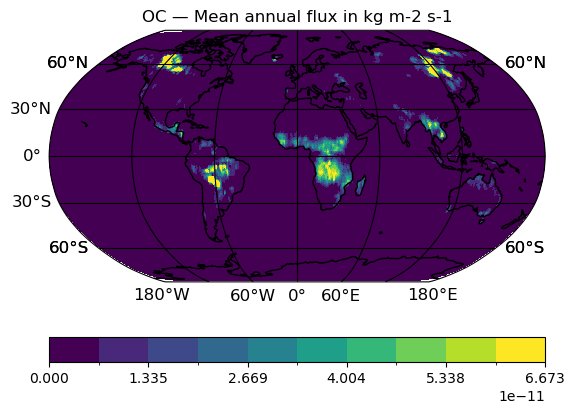

In [69]:
from scipy.interpolate import griddata

da_p_t = da_p.mean(dim="time")

lon = np.rad2deg(da_p_t.clon.values)
lat = np.rad2deg(da_p_t.clat.values)

# Target regular grid
lon_reg = np.linspace(-180, 180, 720)
lat_reg = np.linspace(-90, 90, 360)
lon2d, lat2d = np.meshgrid(lon_reg, lat_reg)

lon = np.rad2deg(da_p_t.clon.values)

# Normalize source to -180 to 180
lon = np.where(lon > 180, lon - 360, lon)

# Now griddata is safe
data_reg = griddata(
    points=(lon, lat),
    values=da_p_t.values,
    xi=(lon2d, lat2d),
    method="linear"
)
# Wrap as xarray Dataset for psyplot
ds_reg = xr.Dataset(
    {"emiss_fire": (["lat", "lon"], data_reg)},
    coords={"lat": lat_reg, "lon": lon_reg}
)

# Get scale from the regridded data (ignores NaNs)
vmin = float(np.nanpercentile(ds_reg['emiss_fire'].values, 2))
vmax = float(np.nanpercentile(ds_reg['emiss_fire'].values, 99.6))

import psyplot.project as psy
psy.plot.mapplot(
    ds_reg,
    name="emiss_fire",
    cmap="viridis",
    projection="robin",
    title=rf"{VARNAME} — Mean annual flux in kg m-2 s-1",
    bounds={"method": "minmax", "vmin": vmin, "vmax": vmax}, 
)

In [ ]:

da_d_t = da_d.mean(dim="time")

psyplot.project.Project([    arr16: 2-dim DataArray of OC, with (lat, lon)=(720, 1440), ])

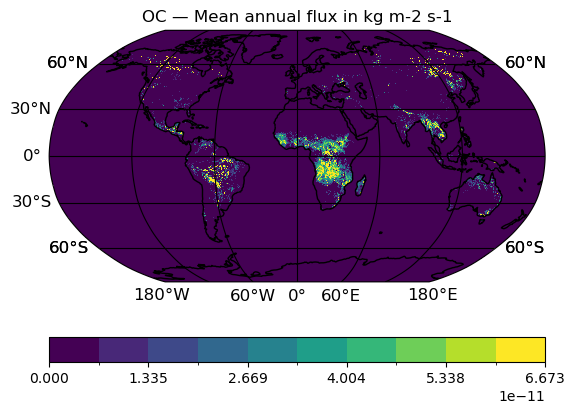

In [70]:

import psyplot.project as psy
psy.plot.mapplot(
    da_d_t.to_dataset(name=VARNAME),
    name=VARNAME,
    cmap="viridis",
    projection="robin",
    title=rf"{VARNAME} — Mean annual flux in kg m-2 s-1",
    bounds={"method": "minmax", "vmin": vmin, "vmax": vmax}, 
)


In [64]:
psy.plot.mapplot.keys('plot')

+------+
| plot |
+------+


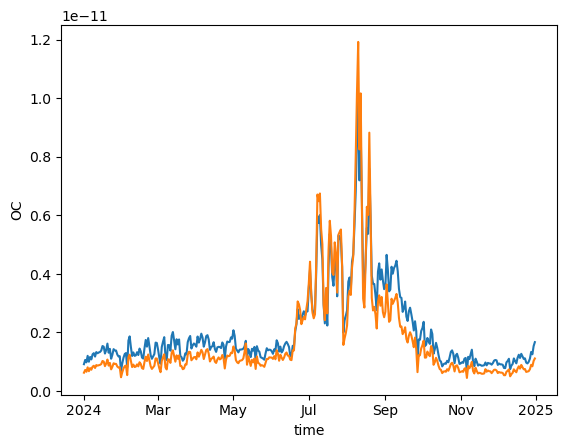

In [76]:
da_p.mean(dim="cell").plot()
da_d.mean(dim=["lon","lat"]).plot()